# Step 3 — The LLM Judge: Vetting the Quiz

Step 2 gave us machine-written multiple-choice questions. But machine-written
means machine-quality: some questions will subtly misread their article. If a
"correct" answer isn't actually supported by the article, Step 4's contestants
get graded against a wrong answer key — and the whole horse race is invalid.

So before any question reaches a contestant, it faces a panel of **three LLM
judges**. Each judge reads the *original article* and the question, and rules
on one thing:

> **faithful** — Is the marked correct option stated or directly supported by
> the article text, with no other option equally defensible?

A question survives only if **at least 2 of the 3 judges** mark it faithful.

This notebook walks the pipeline's three scripts:

| Stage | Script | Output |
|---|---|---|
| Judge (once per model) | `scripts/03-1_generate_judgments.py` | `data/judgments/judgments_<model>.jsonl` |
| Merge to tidy CSV | `scripts/03-2_combine_judgments.py` | `data/judgments/judgments_combined.csv` |
| Seeded selection | `scripts/03-3_select_questions.py` | `data/questions/selected_questions.jsonl` |

We'll make a couple of live judge calls to see the mechanics, then load a
combined CSV (generated at scale from the command line) and **analyze the
judgments with figures**.

## 1. What the judge sees

The judge gets the article (headline + full text), the question with lettered
options, and which option was marked correct. It does **not** see the
generator's explanation — the question must stand on the article alone.

In [1]:
from toolkit import prompts
from toolkit.utils import load_jsonl

questions = load_jsonl("../data/questions/questions_gemini-3.1-flash-lite.jsonl")
articles_by_id = {a["id"]: a for a in load_jsonl("../data/articles/guardian_articles.jsonl")}

question = questions[0]
article = articles_by_id[question["article_id"]]

user_prompt = prompts.build_judge_user_prompt(
    article["headline"],
    article["body_text"],
    question["question"],
    question["options"],
    question["correct_letter"],
)
# The user half: article + question + marked answer (body truncated to peek)
print(user_prompt[:400], "\n   [... full article text ...]\n")
print(user_prompt[user_prompt.find("QUESTION TO JUDGE"):])

ARTICLE HEADLINE: ‘Enemies of civilization’: top Trump officials launch sweeping attack on left

ARTICLE TEXT:
Top Trump officials on Thursday hosted a gathering of 66 nations to discuss the supposed threat of leftwing violence, and launched a series of diatribes, harsh even by the standards of the Trump administration, against leftism. The conference, convened by Marco Rubio, the secretary of sta 
   [... full article text ...]

QUESTION TO JUDGE:
How many nations were represented at the ministerial gathering hosted by Trump administration officials to discuss leftwing violence?

OPTIONS:
A. 44
B. 55
C. 66
D. 77

MARKED CORRECT ANSWER: C



And the system half is the judge's job description — one binary dimension plus
a rationale:

In [2]:
print(prompts.JUDGE_SYSTEM_PROMPT)

You are an expert auditor of quiz questions. Each question was written from a
specific news article; you will see the article, the question, its options,
and which option was marked correct. Judge the question on one dimension,
answering True or False:

- faithful: The MARKED correct option is stated or directly supported by the
  article text (not hallucinated, not contradicted), and no other option is
  equally defensible given the article.

Also give a 1-2 sentence rationale for your verdict.



## 2. One live judgment

Same structured-output machinery as Step 2, different schema: a single
boolean and a short rationale. The Pydantic class *is* the contract:

```python
class Judgment(BaseModel):
    faithful: bool = Field(description="True if the MARKED correct option is stated or directly supported ...")
    rationale: str = Field(description="1-2 sentences explaining the verdict.")
```

In [3]:
from toolkit.judgments import Judgment
from toolkit.providers import openai_provider

verdict, _raw = openai_provider.run_parsed(
    "gpt-5.4-mini-2026-03-17",       # one of the three judge models
    prompts.JUDGE_SYSTEM_PROMPT,
    user_prompt,
    Judgment,
)

print("Question :", question["question"][:90])
print("Marked   :", question["correct_letter"], "—",
      question["options"]["ABCD".index(question["correct_letter"])][:60])
print()
print("faithful =", verdict.faithful)
print("WHY:", verdict.rationale)

Question : How many nations were represented at the ministerial gathering hosted by Trump administrat
Marked   : C — 66

faithful = True
WHY: The article explicitly says the conference was a gathering of 66 nations and that 66 participating countries attended. Therefore option C is directly supported by the text.


## 3. Catching a lie

Does the judge actually read, or does it rubber-stamp? Let's frame an
innocent question: keep everything identical but **mark a wrong option as
correct** — exactly the failure mode (a hallucinated answer key) this step
exists to catch:

In [4]:
wrong_letter = next(l for l in "ABCD" if l != question["correct_letter"])

rigged_prompt = prompts.build_judge_user_prompt(
    article["headline"],
    article["body_text"],
    question["question"],
    question["options"],
    wrong_letter,                     # <- the lie
)
verdict, _raw = openai_provider.run_parsed(
    "gpt-5.4-mini-2026-03-17",
    prompts.JUDGE_SYSTEM_PROMPT,
    rigged_prompt,
    Judgment,
)
print(f"Marked {wrong_letter!r} instead of {question['correct_letter']!r} ->",
      "faithful =", verdict.faithful)
print("WHY:", verdict.rationale)

Marked 'A' instead of 'C' -> faithful = False
WHY: The article explicitly says the conference was attended by representatives of 66 nations. Therefore option C, not A, is directly supported by the text.


## 4. A panel of three judges, at scale

One judge can be wrong — models have blind spots, and a single verdict is a
coin with unknown bias. So we ask **three different models** and take a vote.
Majority voting turns three noisy judges into one robust filter, and
disagreements (as we'll see below) are often the most interesting questions.

Judging hundreds of questions is command-line work, not notebook work — the
same script pattern as Steps 1–2 (threadpool via `--parallel`, crash-safe
appends, resume on question id):

```bash
# 03-1: one run per judge model
for M in gpt-5.6-luna gpt-5.5-2026-04-23 gpt-5.4-mini-2026-03-17; do
  uv run python scripts/03-1_generate_judgments.py \
      --questions data/questions/questions_gemini-3.1-flash-lite.jsonl \
      --articles data/articles/guardian_articles.jsonl \
      --model $M --parallel
done

# 03-2: merge the per-model files into one tidy CSV
uv run python scripts/03-2_combine_judgments.py \
    --input-dir data/judgments --glob 'judgments_*.jsonl'
```

Each judgment row records **both sides of the evaluation** — who wrote the
question (`generator_provider`, `generator_model`) and who judged it
(`judge_model`) — so any later analysis can slice by either.

## 5. Loading the combined judgments

From here on we assume those two commands already ran. We just load the tidy
CSV — one row per (question × judge) — and analyze it:

In [5]:
import pandas as pd

df = pd.read_csv("../data/judgments/judgments_combined.csv")
n_questions = df["question_id"].nunique()
n_judges = df["judge_model"].nunique()

print(f"{len(df)} judgments = {n_questions} questions x {n_judges} judges")
df.head(3)[["question_id", "judge_model", "faithful", "rationale"]]

30 judgments = 10 questions x 3 judges


,question_id,judge_model,faithful,rationale
0,gemini__environment/2026/jul/16/how-green-andy...,gpt-5.4-mini-2026-03-17,True,The article explicitly says Burnham “set a loc...
1,gemini__environment/2026/jul/16/how-green-andy...,gpt-5.5-2026-04-23,True,The article explicitly states that Burnham “se...
2,gemini__environment/2026/jul/16/how-green-andy...,gpt-5.6-luna,True,The article explicitly states that Burnham “se...


## 6. How strict is each judge?

The selection script prints these numbers as text; in a notebook we can *see*
them. First: each judge's pass rate. If one judge is far stricter than the
others, the majority vote is quietly leaning on the other two.

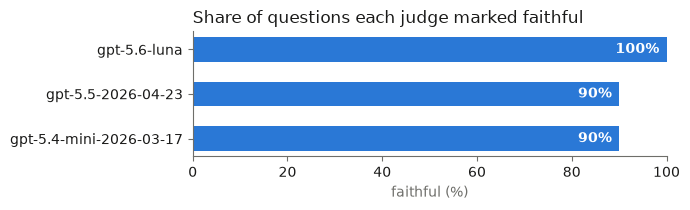

In [6]:
import matplotlib.pyplot as plt

BLUE = "#2a78d6"          # single hue: one measure, light-to-dark reserved for magnitude
NEUTRAL = "#e2e2e0"
INK, MUTED = "#1a1a19", "#6e6e6a"

def clean_axes(ax):
    """Recessive chart furniture: data in front, scaffolding in back."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelcolor=INK)

rates = (df.groupby("judge_model")["faithful"].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(7, 2.2))
bars = ax.barh(rates.index, rates.values, color=BLUE, height=0.55)
for bar, v in zip(bars, rates.values):
    ax.text(v - 1.5, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%",
            ha="right", va="center", color="white", fontweight="bold")
ax.set_xlim(0, 100)
ax.set_title("Share of questions each judge marked faithful", loc="left", color=INK)
ax.set_xlabel("faithful (%)", color=MUTED)
clean_axes(ax)
plt.tight_layout()
plt.show()

## 7. How often do the judges agree?

The vote only matters where judges disagree. This distribution shows how many
questions got 3, 2, 1, or 0 faithful votes — everything left of the 2-vote
line is filtered out:

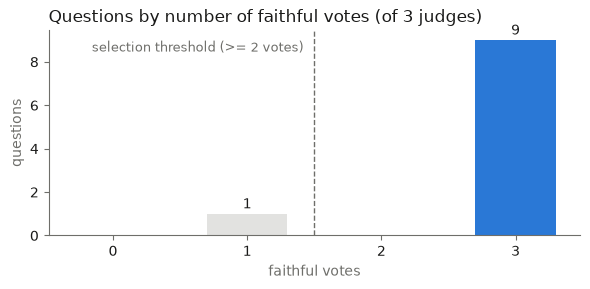

Unanimous verdicts: 90% of questions


In [7]:
votes = df.groupby("question_id")["faithful"].sum().astype(int)
dist = votes.value_counts().reindex(range(n_judges + 1), fill_value=0)

fig, ax = plt.subplots(figsize=(6, 3))
colors = [BLUE if k >= 2 else NEUTRAL for k in dist.index]
bars = ax.bar([str(k) for k in dist.index], dist.values, color=colors, width=0.6)
for bar, v in zip(bars, dist.values):
    if v:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                ha="center", va="bottom", color=INK)
ax.axvline(1.5, color=MUTED, linestyle="--", linewidth=1)
ax.text(1.45, ax.get_ylim()[1] * 0.95, "selection threshold (>= 2 votes) ",
        ha="right", va="top", color=MUTED, fontsize=9)
ax.set_title("Questions by number of faithful votes (of 3 judges)", loc="left", color=INK)
ax.set_xlabel("faithful votes", color=MUTED)
ax.set_ylabel("questions", color=MUTED)
clean_axes(ax)
plt.tight_layout()
plt.show()

unanimous = ((votes == 0) | (votes == n_judges)).mean()
print(f"Unanimous verdicts: {unanimous:.0%} of questions")

## 8. The verdict matrix

Every verdict at once — judges on one axis, questions on the other. Vertical
white stripes are questions *someone* doubted; they're where you should go
read the rationales:

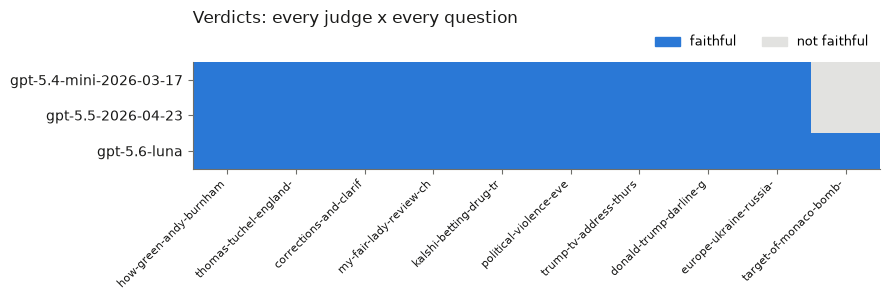

In [8]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

matrix = df.pivot_table(index="judge_model", columns="question_id",
                        values="faithful").astype(int)
matrix = matrix[matrix.sum().sort_values(ascending=False).index]  # passers first

fig, ax = plt.subplots(figsize=(9, 1.6 + 0.5 * len(matrix)))
ax.imshow(matrix.values, cmap=ListedColormap([NEUTRAL, BLUE]),
          aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(matrix.index)), matrix.index)
ax.set_xticks(range(len(matrix.columns)),
              [c.split("/")[-1][:22] for c in matrix.columns],
              rotation=45, ha="right", fontsize=8)
ax.set_title("Verdicts: every judge x every question", loc="left", color=INK, pad=28)
ax.legend(handles=[Patch(color=BLUE, label="faithful"),
                   Patch(color=NEUTRAL, label="not faithful")],
          loc="lower right", bbox_to_anchor=(1.0, 1.02), frameon=False, ncols=2, fontsize=9)
clean_axes(ax)
plt.tight_layout()
plt.show()

And the rationales behind every "not faithful" — the judges explain
themselves, which is what makes this filter auditable rather than a black
box:

In [9]:
fails = df[~df["faithful"]]
for qid, g in fails.groupby("question_id"):
    print(f"FAILED by {len(g)} judge(s): {qid}")
    for _, r in g.iterrows():
        print(f"  {r['judge_model']}: {r['rationale']}\n")

FAILED by 2 judge(s): gemini__world/2026/jul/16/target-of-monaco-bomb-blames-attack-on-ukrainian-spy-agency__q0
  gpt-5.4-mini-2026-03-17: The article says Anastasiia Berezovska was found dead near Kyiv, and separately says the forest where she was allegedly taken and killed was near the village of Yuriv. The marked answer C is not directly supported as the location where her body was discovered; D is the closer match to the text.

  gpt-5.5-2026-04-23: The article says Berezovska was “found dead near Kyiv” and separately says prosecutors allege she was taken to a forest near Yuriv “where she was killed.” It does not directly state that her body was discovered near Yuriv, so the marked answer relies on an inference or conflates the killing location with the discovery location.



## 9. The passing rule and the seeded draw

Selection is two lines of pandas: a question passes when **>= 2 distinct
judges** marked it faithful...

In [10]:
passing = votes[votes >= 2]
print(f"judged {n_questions} -> passing {len(passing)} "
      f"({len(passing) / n_questions:.0%})")

judged 10 -> passing 9 (90%)


...and the final quiz is a **seeded random sample** of the passers. Seeding
matters for research: `random.Random(42).sample(...)` means anyone re-running
the pipeline on the same data draws the *same* questions — reproducibility
for free.

The script wraps both, plus the join back to full question records:

```bash
uv run python scripts/03-3_select_questions.py \
    --input data/judgments/judgments_combined.csv \
    --questions data/questions/questions_gemini-3.1-flash-lite.jsonl
```

In [11]:
!cd .. && uv run python scripts/03-3_select_questions.py \
    --input data/judgments/judgments_combined.csv \
    --questions data/questions/questions_gemini-3.1-flash-lite.jsonl 2>&1 | tail -3

2026-07-16 18:06:13,196 - select_questions - INFO - Unanimous verdicts (all judges agree pass/fail): 90% of questions
2026-07-16 18:06:13,196 - select_questions - WARNING - Only 9 questions pass — fewer than the requested 100; writing all of them.
2026-07-16 18:06:13,203 - select_questions - INFO - Done: judged 10 -> passing 9 (90%) -> selected 9 (seed 42) -> data/questions/selected_questions.jsonl


In [12]:
selected = load_jsonl("../data/questions/selected_questions.jsonl")
print(f"{len(selected)} questions in the final quiz. One of them:\n")
q = selected[0]
print(q["question"])
for letter, option in zip("ABCD", q["options"]):
    mark = "*" if letter == q["correct_letter"] else " "
    print(f"  {mark}{letter}. {option}")
print(f"\n(passed {q['n_models_passing']} of 3 judges)")

9 questions in the final quiz. One of them:

What local target for net zero carbon emissions did Andy Burnham set while serving as mayor of Greater Manchester?
   A. 2030
   B. 2035
  *C. 2038
   D. 2050

(passed 3 of 3 judges)


## 10. The map

| This notebook | Where it lives |
|---|---|
| §1 judge prompts | `toolkit.prompts.JUDGE_SYSTEM_PROMPT`, `build_judge_user_prompt()` |
| §2–3 one judgment | `toolkit.judgments.Judgment`, `judge_question()` |
| §4 panel at scale | `scripts/03-1_generate_judgments.py` (per model) + `toolkit.judgments.judge_questions()` |
| §5 tidy CSV | `scripts/03-2_combine_judgments.py` |
| §6–8 analysis | figures here; the same stats print from `scripts/03-3_select_questions.py` (add `--show-failures` for §8's rationales) |
| §9 selection | `scripts/03-3_select_questions.py` (`--n`, `--seed`, `--min-passing`) |

---

### Next up: Step 4 🏁

We now have a vetted, reproducible quiz. Time to line up the contestants:
the same LLMs answering **closed-book**, **with web search**, and via
**multi-agent debate** — the horses in our race.